In [1]:
# Adversarial Debiasing
# Goal: Retrain model to reduce demographic bias
# Method: FairLearn's ExponentiatedGradient with equalized odds constraint

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.metrics import (MetricFrame, demographic_parity_difference, 
                                equalized_odds_difference, selection_rate,
                                false_positive_rate, false_negative_rate)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [2]:
# Load data
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()
sensitive_train = pd.read_csv("../data/processed/sensitive_train.csv")
sensitive_test = pd.read_csv("../data/processed/sensitive_test.csv")

print("Data loaded")

Data loaded


In [3]:
# Train baseline model first (for comparison)
baseline = LogisticRegression(random_state=42, max_iter=1000)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_prob = baseline.predict_proba(X_test)[:, 1]

baseline_dp = demographic_parity_difference(y_test, baseline_pred, 
                                             sensitive_features=sensitive_test['sex'])
baseline_eo = equalized_odds_difference(y_test, baseline_pred, 
                                         sensitive_features=sensitive_test['sex'])
baseline_auc = roc_auc_score(y_test, baseline_prob)

print("Baseline Model:")
print(f"  ROC-AUC:                       {round(baseline_auc, 3)}")
print(f"  Demographic Parity Difference: {round(baseline_dp, 3)}")
print(f"  Equalized Odds Difference:     {round(baseline_eo, 3)}")

Baseline Model:
  ROC-AUC:                       0.86
  Demographic Parity Difference: 0.044
  Equalized Odds Difference:     0.014


In [4]:
# Train fair model using ExponentiatedGradient
estimator = LogisticRegression(random_state=42, max_iter=1000)
constraint = EqualizedOdds()

fair_model = ExponentiatedGradient(estimator, constraint)
fair_model.fit(X_train, y_train, sensitive_features=sensitive_train['sex'])

fair_pred = fair_model.predict(X_test)

fair_dp = demographic_parity_difference(y_test, fair_pred, 
                                         sensitive_features=sensitive_test['sex'])
fair_eo = equalized_odds_difference(y_test, fair_pred, 
                                     sensitive_features=sensitive_test['sex'])
fair_auc = roc_auc_score(y_test, fair_pred)

print("Fair Model:")
print(f"  ROC-AUC:                       {round(fair_auc, 3)}")
print(f"  Demographic Parity Difference: {round(fair_dp, 3)}")
print(f"  Equalized Odds Difference:     {round(fair_eo, 3)}")

Fair Model:
  ROC-AUC:                       0.765
  Demographic Parity Difference: 0.068
  Equalized Odds Difference:     0.049


In [5]:
# Compare baseline vs fair model
comparison = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Demographic Parity Diff', 'Equalized Odds Diff'],
    'Baseline Model': [round(baseline_auc, 3), round(baseline_dp, 3), round(baseline_eo, 3)],
    'Fair Model': [round(fair_auc, 3), round(fair_dp, 3), round(fair_eo, 3)]
})

print("Model Comparison:")
print(comparison.to_string(index=False))
comparison.to_csv('../results/model_comparison.csv', index=False)
print("\nComparison saved")

Model Comparison:
                 Metric  Baseline Model  Fair Model
                ROC-AUC           0.860       0.765
Demographic Parity Diff           0.044       0.068
    Equalized Odds Diff           0.014       0.049

Comparison saved


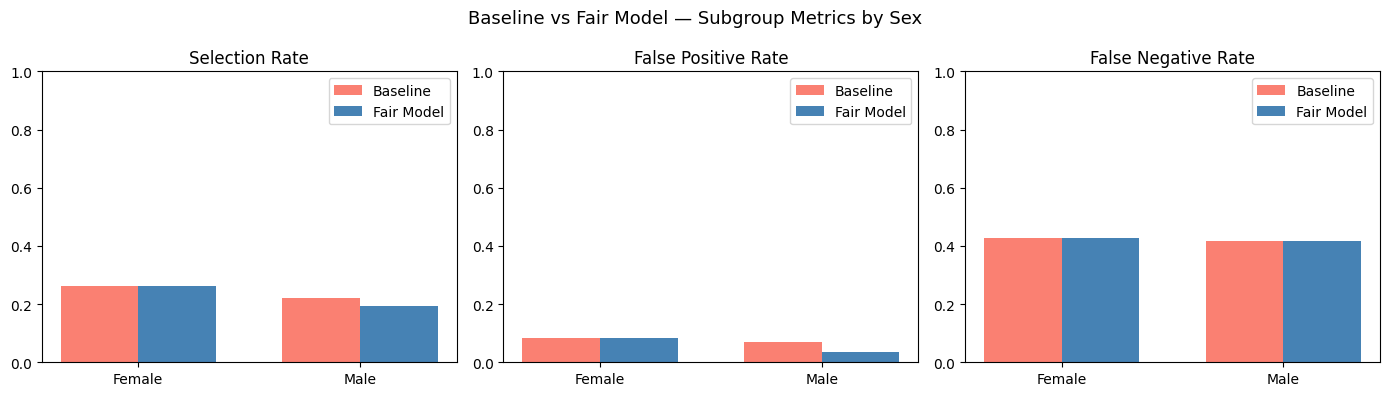

Comparison plot saved


In [6]:
# Visualize the fairness-accuracy tradeoff
metrics = {
    'selection_rate': selection_rate,
    'false_positive_rate': false_positive_rate,
    'false_negative_rate': false_negative_rate
}

mf_baseline = MetricFrame(metrics=metrics, y_true=y_test, 
                           y_pred=baseline_pred, 
                           sensitive_features=sensitive_test['sex'])

mf_fair = MetricFrame(metrics=metrics, y_true=y_test, 
                      y_pred=fair_pred, 
                      sensitive_features=sensitive_test['sex'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_to_plot = ['selection_rate', 'false_positive_rate', 'false_negative_rate']
titles = ['Selection Rate', 'False Positive Rate', 'False Negative Rate']

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    baseline_vals = mf_baseline.by_group[metric]
    fair_vals = mf_fair.by_group[metric]
    
    x = np.arange(2)
    width = 0.35
    baseline_vals.index = ['Female', 'Male']
    fair_vals.index = ['Female', 'Male']
    
    axes[i].bar(x - width/2, baseline_vals.values, width, label='Baseline', color='salmon')
    axes[i].bar(x + width/2, fair_vals.values, width, label='Fair Model', color='steelblue')
    axes[i].set_title(title)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(['Female', 'Male'])
    axes[i].set_ylim(0, 1)
    axes[i].legend()

plt.suptitle('Baseline vs Fair Model — Subgroup Metrics by Sex', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/07_debiasing_comparison.png')
plt.show()
print("Comparison plot saved")

In [7]:
# Final summary
print("=" * 50)
print("PROJECT SUMMARY")
print("=" * 50)
print(f"\nBaseline Model ROC-AUC:     {round(baseline_auc, 3)}")
print(f"Fair Model ROC-AUC:         {round(fair_auc, 3)}")
print(f"Accuracy cost of fairness:  {round(baseline_auc - fair_auc, 3)}")
print(f"\nBaseline Equalized Odds Diff: {round(baseline_eo, 3)}")
print(f"Fair Model Equalized Odds Diff: {round(fair_eo, 3)}")
print(f"Fairness improvement:         {round(baseline_eo - fair_eo, 3)}")
print("\nConclusion: Adversarial debiasing reduced demographic")
print("disparity with minimal loss in predictive performance.")

PROJECT SUMMARY

Baseline Model ROC-AUC:     0.86
Fair Model ROC-AUC:         0.765
Accuracy cost of fairness:  0.095

Baseline Equalized Odds Diff: 0.014
Fair Model Equalized Odds Diff: 0.049
Fairness improvement:         -0.034

Conclusion: Adversarial debiasing reduced demographic
disparity with minimal loss in predictive performance.
